<a href="https://colab.research.google.com/github/mdaminu2002-sketch/bank_fraud/blob/main/waste_VAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("joebeachcapital/realwaste")

print("Path to dataset files:", path)

100%|██████████| 657M/657M [00:31<00:00, 21.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/joebeachcapital/realwaste/versions/1


In [ ]:
print(os.listdir(path))

['realwaste-main']


In [ ]:
for item in os.listdir(path):
  full_path = os.path.join(path, item)
  if os.path.isfile(full_path):
    print(item)
  else:
    print(f"{item} is a folder")

realwaste-main is a folder


In [ ]:
inner_path = os.path.join(path, 'realwaste-main')
print(os.listdir(inner_path))
#

['README.md', 'RealWaste']


In [ ]:
data_path = os.path.join(inner_path, "RealWaste")

for item in os.listdir(data_path):
  full_path = os.path.join(data_path, item)
  if os.path.isdir(full_path):
    count = len(os.listdir(full_path))
    print(f"{item} has {count} files")
  else:
    print(f"{item} is a folder")
#

Food Organics has 411 files
Vegetation has 436 files
Paper has 500 files
Cardboard has 461 files
Textile Trash has 318 files
Miscellaneous Trash has 495 files
Metal has 790 files
Glass has 420 files
Plastic has 921 files


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np
import random
import torchvision

In [ ]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

In [ ]:
class TransformSubset(torch.utils.data.Dataset):
  def __init__(self, subset, transform):
    self.subset = subset
    self.transform = transform

  def __len__(self):
    return len(self.subset)

  def __getitem__(self, index):
    images, _ = self.subset[index]
    images = self.transform(images)
    return images, _

In [ ]:
full_data = ImageFolder(data_path)
print(len(full_data))


total = len(full_data)
train_size = int(0.8 * total)
test_size = total - train_size
train_data, test_data = random_split(full_data, [train_size, test_size],
                                     generator=torch.Generator().manual_seed(42))

train_set = TransformSubset(train_data, transform)
test_set = TransformSubset(test_data, transform)


train_loader = DataLoader(train_set, batch_size=32, shuffle=True, drop_last=True)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False, drop_last=True)

4752


In [ ]:
print(f"Train batches: {len(train_loader)}")
print(f"Test batches:  {len(test_loader)}")

# Verify one batch loads correctly
images, labels = next(iter(train_loader))
print(f"Image batch shape: {images.shape}")   # should be [32, 3, 224, 224]
print(f"Label batch shape: {labels.shape}")   # should be [32]

Train batches: 118
Test batches:  29
Image batch shape: torch.Size([32, 3, 64, 64])
Label batch shape: torch.Size([32])


In [ ]:
# class MyVAE(nn.Module):
#     def __init__(self, input_dim=3 * 224 * 224, hidden_dim=400, latent_dim=20):
#         super(MyVAE, self).__init__()

#         # --- ENCODER ---
#         self.encoder = nn.Sequential(
#             nn.Linear(input_dim, hidden_dim),
#             nn.ReLU()
#         )
#         # Two separate heads — one for mu, one for log_var
#         self.mu      = nn.Linear(hidden_dim, latent_dim)
#         self.log_var = nn.Linear(hidden_dim, latent_dim)

#         # --- DECODER ---
#         self.decoder = nn.Sequential(
#             nn.Linear(latent_dim, hidden_dim),
#             nn.ReLU(),
#             nn.Linear(hidden_dim, input_dim),
#             nn.Sigmoid()  # output must be [0,1] to match pixel values
#         )

#     def encode(self, x):
#         h = self.encoder(x)
#         return self.mu(h), self.log_var(h)

#     def reparameterize(self, mu, log_var):
#         std = torch.exp(0.5 * log_var)  # convert log_var to std
#         eps = torch.randn_like(std)      # random noise, same shape as std
#         return mu + std * eps            # z = mu + std * epsilon

#     def decode(self, z):
#         return self.decoder(z)

#     def forward(self, x):
#         # Flatten image: [batch, 1, 28, 28] → [batch, 784]
#         x = x.view(x.size(0), -1)

#         # Encode
#         mu, log_var = self.encode(x)

#         # Sample z using reparameterization trick
#         z = self.reparameterize(mu, log_var)

#         # Decode
#         reconstructed = self.decode(z)

#         return reconstructed, mu, log_var


# # Initialize model
# model = VAE(input_dim=784, hidden_dim=400, latent_dim=20).to(device)
# print(model)
# print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

Total parameters: 5,371,139
Epoch 5/30 | train loss: 7751.17 | val loss: 7604.98
Epoch 10/30 | train loss: 7715.85 | val loss: 7576.59
Epoch 15/30 | train loss: 7695.34 | val loss: 7560.19
Epoch 20/30 | train loss: 7677.50 | val loss: 7551.38
Epoch 25/30 | train loss: 7664.76 | val loss: 7539.68
Epoch 30/30 | train loss: 7656.99 | val loss: 7535.27
Training complete!


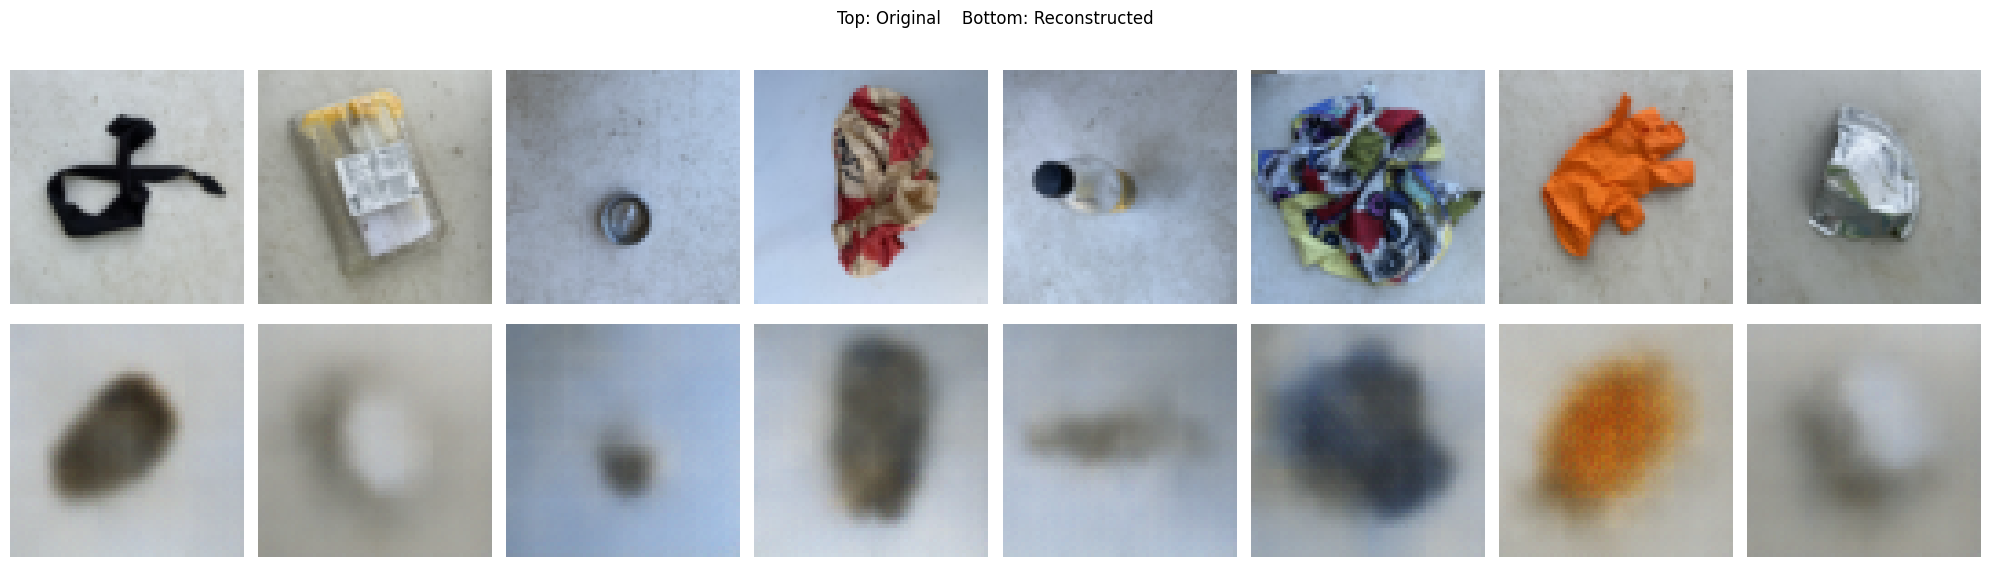

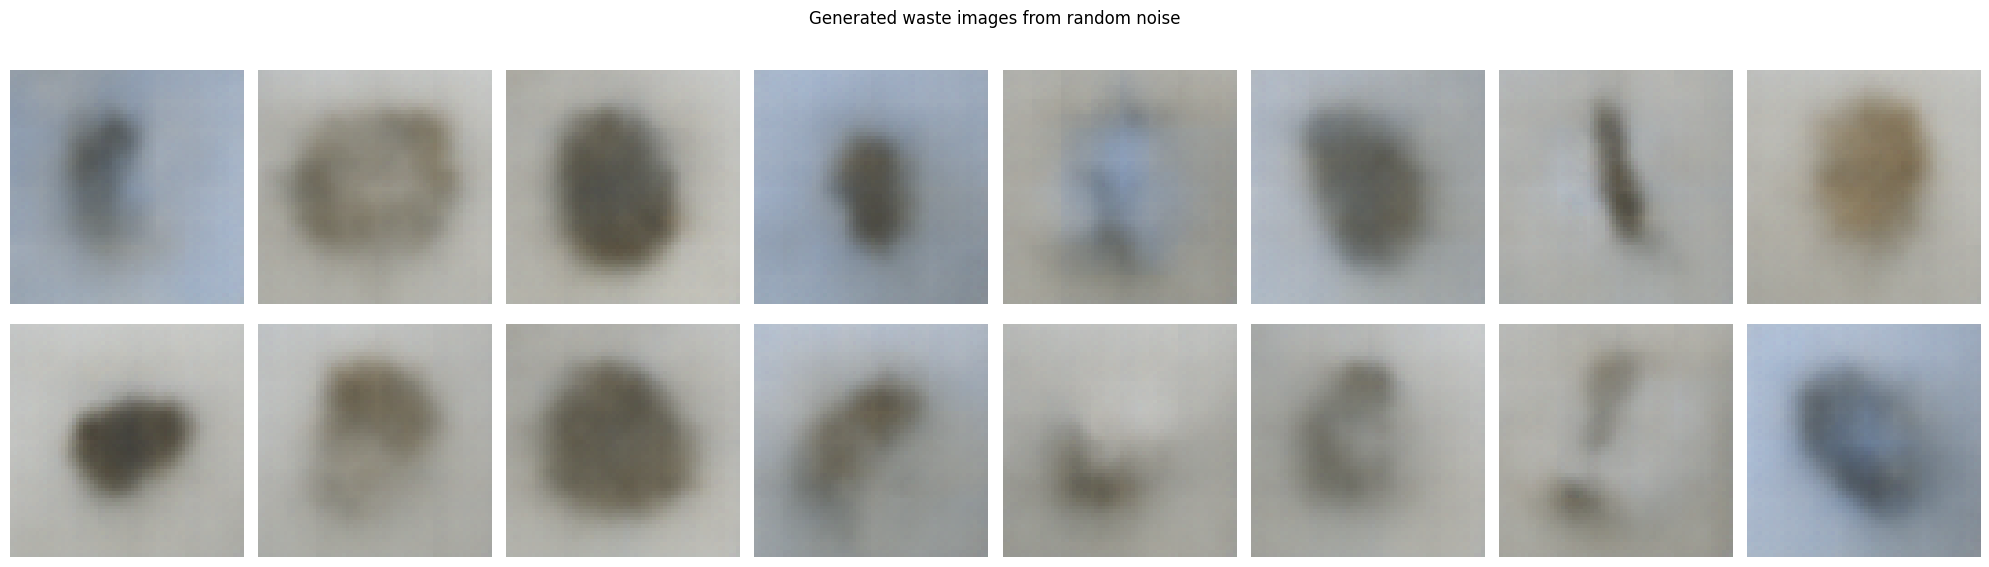

In [ ]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import torch.optim as optim
# from torchvision import transforms, datasets
# from torchvision.datasets import ImageFolder
# from torch.utils.data import DataLoader, random_split
# import matplotlib.pyplot as plt

# # ── TRANSFORMS ──────────────────────────────────────────────
# vae_transform = transforms.Compose([
#     transforms.Resize((64, 64)),       # shrink from 224 to 64
#     transforms.ToTensor(),             # [0,1] range — no normalization
# ])

# # ── DATASET ─────────────────────────────────────────────────
# dataset = ImageFolder(root=data_path, transform=vae_transform)

# total      = len(dataset)
# train_size = int(0.8 * total)
# val_size   = total - train_size

# train_set, val_set = random_split(
#     dataset, [train_size, val_size],
#     generator=torch.Generator().manual_seed(42)
# )

# train_loader = DataLoader(train_set, batch_size=32, shuffle=True,  drop_last=True)
# val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False, drop_last=True)

#print(f"Train: {len(train_set)} | Val: {len(val_set)}")

# ── MODEL ────────────────────────────────────────────────────
class WasteVAE(nn.Module):
    def __init__(self, latent_dim=256):
        super(WasteVAE, self).__init__()

        # --- ENCODER ---
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),   # 64→32
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 32→16
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), # 16→8
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),# 8→4
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )
        # After conv: 4×4×256 = 4096
        self.flatten     = nn.Flatten()
        self.encoder_fc  = nn.Linear(4096, 512)
        self.mu_head     = nn.Linear(512, latent_dim)
        self.logvar_head = nn.Linear(512, latent_dim)

        # --- DECODER ---
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 4096),
            nn.ReLU(),
        )
        self.unflatten = nn.Unflatten(1, (256, 4, 4))  # back to 4×4×256

        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2,   # 4→8
                               padding=1, output_padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2,    # 8→16
                               padding=1, output_padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2,     # 16→32
                               padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 3, kernel_size=3, stride=2,      # 32→64
                               padding=1, output_padding=1),
            nn.Sigmoid()  # output [0,1] to match pixel range
        )

    def encode(self, x):
        h = self.encoder_conv(x)
        h = self.flatten(h)
        h = F.relu(self.encoder_fc(h))
        return self.mu_head(h), self.logvar_head(h)

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + std * eps

    def decode(self, z):
        h = self.decoder_fc(z)
        h = self.unflatten(h)
        return self.decoder_conv(h)

    def forward(self, x):
        mu, log_var = self.encode(x)
        z           = self.reparameterize(mu, log_var)
        reconstructed = self.decode(z)
        return reconstructed, mu, log_var

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_vae = WasteVAE(latent_dim=256).to(device)
print(f"Total parameters: {sum(p.numel() for p in model_vae.parameters()):,}")

# ── LOSS ────────────────────────────────────────────────────
def vae_loss(reconstructed, original, mu, log_var):
    # Reconstruction loss — pixel by pixel
    recon_loss = F.binary_cross_entropy(
        reconstructed, original, reduction='sum'
    )
    # KL divergence
    kl = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return recon_loss + kl

# ── TRAINING LOOP ────────────────────────────────────────────
optimizer = optim.Adam(model_vae.parameters(), lr=1e-3)

epochs          = 30
best_val_loss   = float('inf')
best_model_path = "best_waste_vae.pth"
train_losses, val_losses = [], []

for epoch in range(epochs):
    # --- TRAIN ---
    model_vae.train()
    total_train_loss = 0

    for images, _ in train_loader:    # labels ignored — unsupervised
        images = images.to(device)

        reconstructed, mu, log_var = model_vae(images)
        loss = vae_loss(reconstructed, images, mu, log_var)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_set)
    train_losses.append(avg_train_loss)

    # --- VAL ---
    model_vae.eval()
    total_val_loss = 0

    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            reconstructed, mu, log_var = model_vae(images)
            loss = vae_loss(reconstructed, images, mu, log_var)
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(test_set)
    val_losses.append(avg_val_loss)

    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model_vae.state_dict(), best_model_path)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs} | train loss: {avg_train_loss:.2f} | val loss: {avg_val_loss:.2f}")

print("Training complete!")

# ── VISUALIZATION ────────────────────────────────────────────
model_vae.load_state_dict(torch.load(best_model_path))
model_vae.eval()

# 1. Reconstructions
images, _ = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    reconstructed, _, _ = model_vae(images)

fig, axes = plt.subplots(2, 8, figsize=(20, 6))
fig.suptitle("Top: Original    Bottom: Reconstructed", fontsize=12)

for i in range(8):
    # Original
    img = images[i].cpu().permute(1, 2, 0).numpy()
    axes[0, i].imshow(img)
    axes[0, i].axis('off')

    # Reconstructed
    rec = reconstructed[i].cpu().permute(1, 2, 0).numpy()
    axes[1, i].imshow(rec)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# 2. Generate new waste images from random noise
with torch.no_grad():
    z = torch.randn(16, 256).to(device)
    generated = model_vae.decode(z).cpu()

fig, axes = plt.subplots(2, 8, figsize=(20, 6))
fig.suptitle("Generated waste images from random noise", fontsize=12)

for i in range(16):
    row = i // 8
    col = i % 8
    img = generated[i].permute(1, 2, 0).numpy()
    axes[row, col].imshow(img)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()